# 🏟️ Circuit analysis

Before delving into this weekend's specifics, how about we take a look on what happened historically in this GP before?

As we try to keep a secret where this race is taking place, the circuit analysis will be very limited.

Note: for simplifying this analysis, let's consider that we have the same weather conditions throughout the sessions. This analysis will not involve rain.

In [1]:
import os

import fastf1 as ff1
from dotenv import load_dotenv
from fastf1 import plotting
from fastf1.logger import set_log_level

from plots.laps import (
    plot_laptime_correlation_heatmap,
    plot_position_correlation_heatmap,
)
from processing.incidents import get_all_incidents_data

load_dotenv()

set_log_level("ERROR")
plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")

TEAM = os.getenv("TEAM")
EVENT_YEAR = int(os.getenv("EVENT_YEAR"))
GP_NAME = os.getenv("GP_NAME")

%matplotlib widget

## ⚙️ Environment setup

## 📚 Aggregating and cleaning data

### ⛏️ Extracting data

In [2]:
race_2021 = ff1.get_session(EVENT_YEAR - 4, GP_NAME, "R")
# In 2022, the GP did not happen.
race_2023 = ff1.get_session(EVENT_YEAR - 2, GP_NAME, "R")
last_year_race = ff1.get_session(EVENT_YEAR - 1, GP_NAME, "R")

In [3]:
race_2021.load(telemetry=False, weather=False)
race_2023.load(telemetry=False, weather=False)
last_year_race.load(telemetry=False, weather=False)

### 📚 Aggregating data

In [4]:
incidents = get_all_incidents_data([race_2021, race_2023, last_year_race])

### ✨ Feature engineering

In [5]:
last_year_race_laps = last_year_race.laps.pick_quicklaps().copy()
last_year_race_laps["LapTime_s"] = last_year_race_laps["LapTime"].dt.total_seconds()

We will filter out push laps as well

In [6]:
last_year_push_laps = last_year_race_laps.pick_quicklaps().copy()

## 🏎️ Race analysis

### 🏅 Last year, what were the most important metrics for achieving good positions on this track?

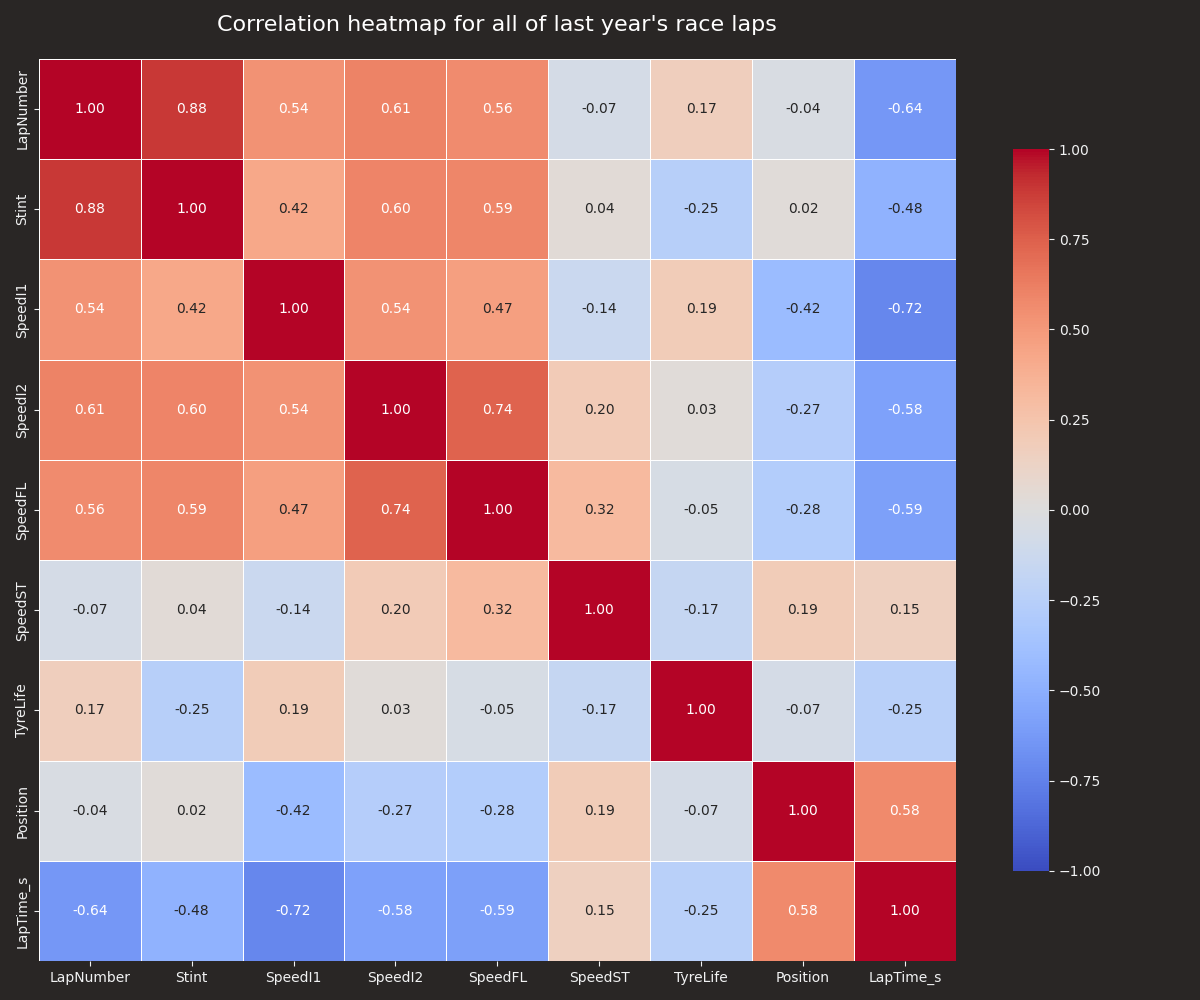


--- Correlations with position ---
LapTime_s     0.58
SpeedI1      -0.42
SpeedFL      -0.28
SpeedI2      -0.27
SpeedST       0.19
TyreLife     -0.07
LapNumber    -0.04
Stint         0.02
Name: Position, dtype: object


In [7]:
plot_position_correlation_heatmap(
    last_year_race_laps,
    title="Correlation heatmap for all of last year's race laps",
)

From the data analyzed, lap time has as strong correlation with positions on this Grand Prix, the highest index.

Also, speed on the first intermediate of the circuit is the second most correlated feature, achieving a moderate index of -0.42.

The other speed features also have lower but significant correlation values to position.

### 🕒 What are, historically, the most important metrics for achieving good lap times on this track?

Since lap times are the most important feature to obtain results in the race, and the main target of most engineering, let's check how we can achieve lower lap times in this circuit. We will filter only push laps (107% of fastest lap).

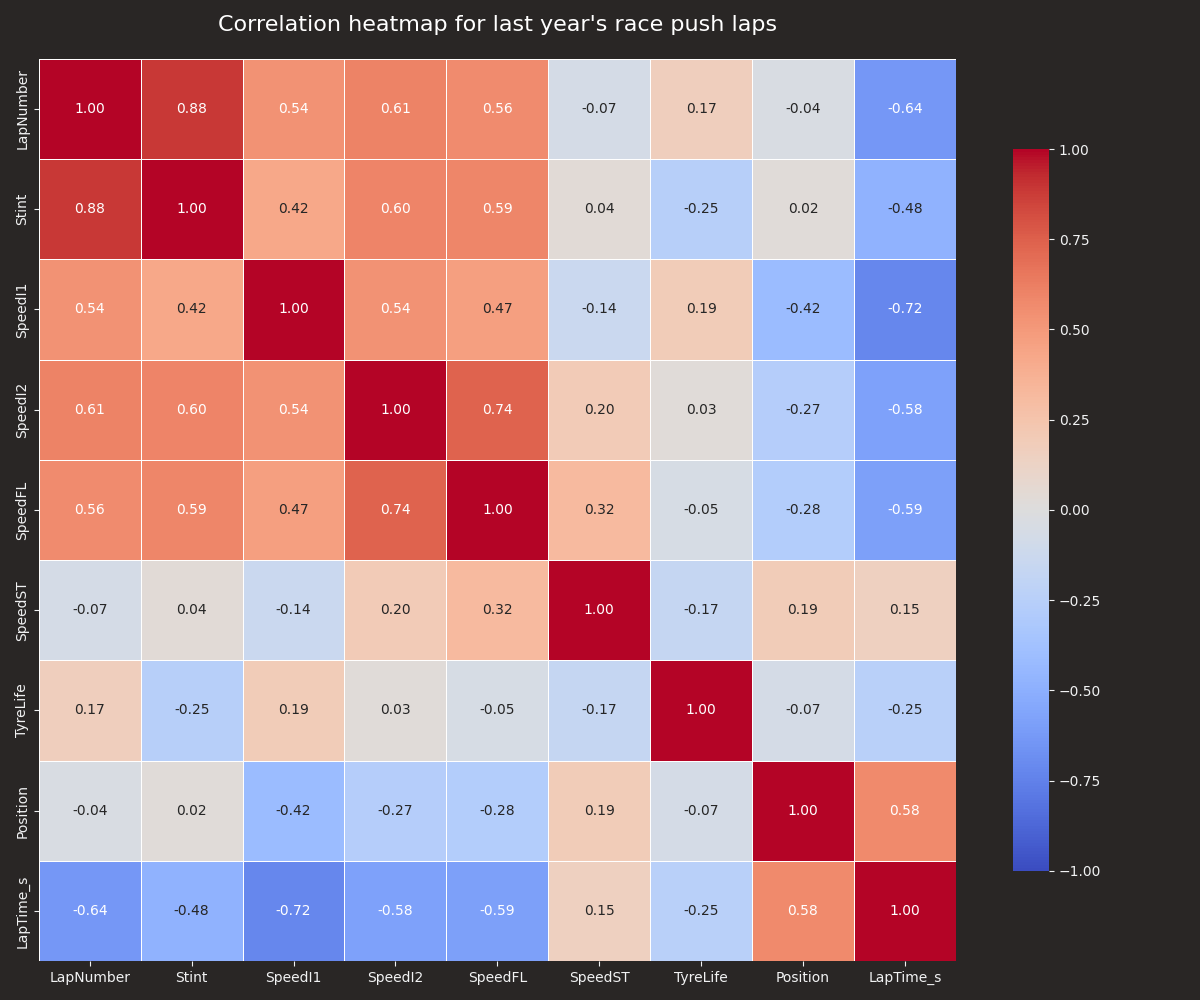


--- Correlations with lap time ---
SpeedI1      -0.72
LapNumber    -0.64
SpeedFL      -0.59
SpeedI2      -0.58
Position      0.58
Stint        -0.48
TyreLife     -0.25
SpeedST       0.15
Name: LapTime_s, dtype: object


In [8]:
plot_laptime_correlation_heatmap(
    last_year_push_laps,
    title="Correlation heatmap for last year's race push laps",
)

It seems that speed through the first intermediat has the strongest correlation with respect to achieving lower lap times (-0.72), while other speed values also pose strong correlations, such as speed on the finishing line (-0.59) and the second intermediate (-0.58).

Stint, that is, how many laps a given tyre has been used for before pits also poses a strong correlation (-0.48). That is, as the stint increases, the lap times generally get faster. However, it is import to be wary of this correlation as this is the final output of the race strategies of the teams. Their efforts are focused on essentially increasing this correlation to improve lap times.

Also be wary: lap number is a proxy variable. The lap number itself doesn't magically push the car down the track faster, rather, it is a direct measurement of elapsed distance and work.

### 🚩 How many race incidents happen on this circuit?

While a correlation of 0.58 demonstrates a clear relationship, it also highlights that raw lap time alone does not dictate the outcome. This substantial proportion of unexplained variance suggests that secondary variables - such as race strategy - play a critical role in the outcome of the  race.

A big part of the race strategy in F1 races are pit stops, tyre management and opportunistic and strategic handling of safety car deployments. 

As safety cars can shuffle strategies a lot, let's take a look at how many race incidents happened in the previous iterations of this Grand Prix.

In [9]:
print(
    f"There has been a total of {len(incidents)} incidents in the recent years of this",
    "GP that resulted in a red, yellow or black flag being deployed.",
)

There has been a total of 13 incidents in the recent years of this GP that resulted in a red, yellow or black flag being deployed.


In [10]:
print(
    f"That amounts to a mean of {len(incidents) / len(incidents.Year.unique()):.2f}",
    "incidents per race.",
)

That amounts to a mean of 4.33 incidents per race.


In [11]:
min_incidents = incidents.groupby("Year").size().min()
print(
    "In recent years, the race with the lowest recorded number of incidents had",
    f"{min_incidents} incidents.",
)

In recent years, the race with the lowest recorded number of incidents had 3 incidents.


In [12]:
last_year_incidents = len(incidents[incidents["Year"] == EVENT_YEAR - 1])
print(f"Last year, {last_year_incidents} of these flags were issued.")

Last year, 5 of these flags were issued.


## 💡 Summary and conclusions

The most important factor for finishing position at this circuit is lap time, which showed the strongest correlation with race results — the highest of all metrics analyzed.

The second most impactful metric for positions was speed through the first intermediate sector (correlation of −0.42), suggesting this section of the circuit is particularly decisive for performance.

### 🕒 What drives fast lap times?

Looking specifically at push laps (laps within 107% of the fastest lap), the analysis found:
- **Speed through the first intermediate** has the strongest correlation with lower lap times (−0.72).
- **Finishing line speed and second intermediate speed** are also strongly correlated (−0.59 and −0.58, respectively).
- **Tyre stint length** shows a notable correlation (−0.48) — lap times generally improve as the stint progresses, reflecting team strategy and tyre warm-up. This is an effect of strategy and tyre management choices!

### ♟️ Race stategies

Despite the strong lap time correlation with position (0.58), there's significant unexplained variance, pointing to the importance of strategy — pit stops, tyre management, and response to safety cars.

The notebook computed historical flag incidents (red, yellow, and black flags) across the race editions analyzed, examining total incidents (13), the **mean per race (4.3)**, the **minimum in a single year (3)**, and **last year's count (5)**.

## 🌱 Future works and improvements